In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame
data = {
    'symbol': ['AAPL', 'AAPL', 'AAPL', 'AAPL', 'ABBV', 'ABBV', 'ABBV', 'ABBV', 'AON', 'AON'],
    'month_start_date': ['2024-06-10', '2024-07-01', '2024-08-01', '2024-09-03', '2024-06-10', '2024-07-01', '2024-08-01', '2024-09-03', '2024-06-10', '2024-07-01'],
    'month_start_price': [193.119995, 216.750000, 218.360001, 222.770004, 170.460007, 170.369995, 189.710007, 197.690002, 286.859985, 293.489990],
    'month_end_price': [210.619995, 222.080002, 229.000000, 220.850006, 171.520004, 185.320007, 196.309998, 197.009995, 293.579987, 328.510010]
}

df = pd.DataFrame(data)

# Convert month_start_date to datetime
df['month_start_date'] = pd.to_datetime(df['month_start_date'])

# Get the last two months
last_two_months = df['month_start_date'].max() - pd.DateOffset(months=2)
print(f"last_two_months : {last_two_months}")
last_two_months = pd.date_range(start=last_two_months, end=df['month_start_date'].max(), freq='MS').strftime('%Y-%m')
print(f"last_two_months : {last_two_months}")

# Filter the DataFrame for the last two months and make a copy
filtered_df = df[df['month_start_date'].dt.to_period('M').astype(str).isin(last_two_months)].copy()

# Create a 'month' column for plotting
filtered_df['month'] = filtered_df['month_start_date'].dt.to_period('M').astype(str)

print(filtered_df)


last_two_months : 2024-07-03 00:00:00
last_two_months : Index(['2024-08', '2024-09'], dtype='object')
  symbol month_start_date  month_start_price  month_end_price    month
2   AAPL       2024-08-01         218.360001       229.000000  2024-08
3   AAPL       2024-09-03         222.770004       220.850006  2024-09
6   ABBV       2024-08-01         189.710007       196.309998  2024-08
7   ABBV       2024-09-03         197.690002       197.009995  2024-09


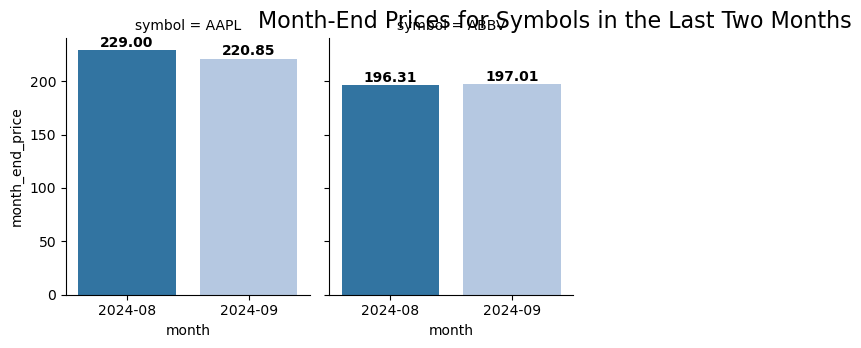

In [32]:
# Plot using catplot
g = sns.catplot(x="month", y="month_end_price", col="symbol", hue="month", col_wrap=4,
                data=filtered_df,
                kind="bar", height=3.5, aspect=.8, 
                palette='tab20')

# Display actual values on top of bars
for ax in g.axes.flat:
    for p in ax.patches:  # Iterate over each bar
        height = p.get_height()  # Get the height of the bar
        ax.text(p.get_x() + p.get_width() / 2, height + 0.5,  # Position text slightly above the bar
                f'{height:.2f}',  # Display value with two decimal places
                ha='center', va='bottom', fontsize=10, fontweight='bold')  # Center text

# Set a more descriptive title
g.fig.suptitle('Month-End Prices for Symbols in the Last Two Months', fontsize=16)

# Adjust the layout to prevent title overlap
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust this value as needed

plt.show()

In [47]:
# Create a color column based on price comparison
def determine_colors(group):
    colors = []
    for i in range(len(group)):
        if i % 2 == 0:
            colors.append('lightgrey')  # First month bar color
        elif row['month_end_price'] > row['month_start_price']:
            colors.append('green')  # Second month bar color
        else:
            colors.append('grey')
    return colors

# Apply the color function to each symbol group
filtered_df['color'] = filtered_df.groupby('symbol').apply(determine_colors).reset_index(level=0, drop=True)

# Plot using catplot with a custom color palette
g = sns.catplot(x="month", y="month_end_price", col="symbol", hue="month", col_wrap=4,
                data=filtered_df,
                kind="bar", height=3.5, aspect=.8, 
                palette={'2024-06': 'lightgrey', '2024-07': 'green', '2024-08': 'green', '2024-09': 'green'})

# Display actual values on top of bars
for ax in g.axes.flat:
    for p in ax.patches:  # Iterate over each bar
        height = p.get_height()  # Get the height of the bar
        color = p.get_facecolor()  # Use bar color
        ax.text(p.get_x() + p.get_width() / 2, height + 0.5,  # Position text slightly above the bar
                f'{height:.2f}',  # Display value with two decimal places
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)  # Center text

# Set a more descriptive title
g.fig.suptitle('Month-End Prices for Symbols in the Last Two Months', fontsize=16)

# Adjust the layout to prevent title overlap
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust this value as needed

plt.show()

NameError: name 'row' is not defined